# Diabetes Prediction Project

## Overview
The goal of this project is to build a machine learning model to predict whether a patient has diabetes based on medical features.

This is a binary classification problem where:
- 0 = No Diabetes
- 1 = Diabetes

## Dataset Description
The dataset includes the following features:
- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age

Target variable:
- Outcome

## Objective
- Perform exploratory data analysis (EDA)
- Clean and preprocess the data
- Train a machine learning model
- Evaluate the model performance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv('diabetes.csv')

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.shape

(768, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## Missing Values Observation

The dataset does not show any missing values initially. However, certain columns such as Glucose, BloodPressure, SkinThickness, Insulin, and BMI contain zero values which are not realistic.

These zero values will be treated as missing values and handled accordingly.

In [7]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols] = df[cols].replace(0, np.nan)

In [8]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [9]:
df.fillna(df.median(), inplace=True)

In [10]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

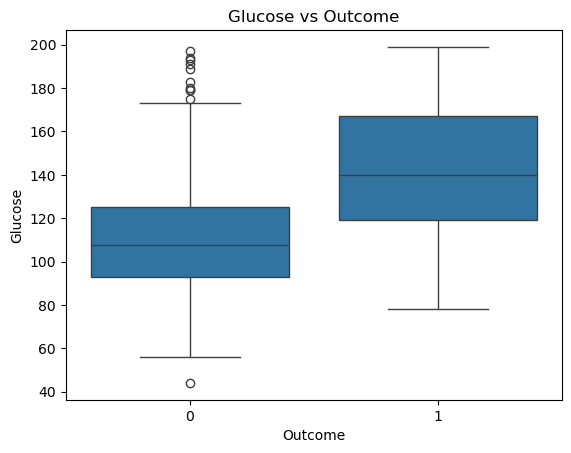

In [11]:
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title('Glucose vs Outcome')
plt.show()

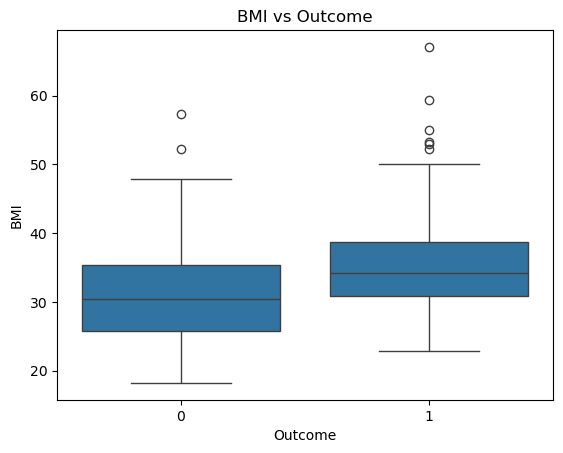

In [12]:
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.title('BMI vs Outcome')
plt.show()

## Visualization Insights

The visualizations show that individuals with higher glucose and BMI levels are more likely to have diabetes.

These features appear to be strong predictors and will likely play an important role in the model.

## Feature Scaling

Feature scaling is important when features have different ranges. 

For example, glucose values are much larger than BMI or age. Without scaling, some machine learning models may give more importance to larger values.

Therefore, we apply standardization to normalize the data so that each feature has a mean of 0 and standard deviation of 1.

In [13]:
df[['Glucose', 'BMI']].head()

,Glucose,BMI
0,148.0,33.6
1,85.0,26.6
2,183.0,23.3
3,89.0,28.1
4,137.0,43.1


In [16]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [18]:
X_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.866045,-0.031990,0.670643,-0.181541,0.166619,0.468492,1.425995
1,-0.844885,-1.205066,-0.528319,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672
2,1.233880,2.016662,-0.693761,-0.012301,-0.181541,-1.332500,0.604397,-0.105584
3,-0.844885,-1.073567,-0.528319,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549
4,-1.141852,0.504422,-2.679076,0.670643,0.316566,1.549303,5.484909,-0.020496


## Feature Summary

The table above summarizes each feature in the dataset including data type, number of missing values, and number of unique values.

All features in this dataset are numerical.

After handling missing values, there are no remaining missing values.

The features have different ranges and distributions, which is why scaling was applied before training the model.

In [19]:
summary = pd.DataFrame({
    'Feature': df.columns,
    'Data Type': df.dtypes.values,
    'Missing Values': df.isnull().sum().values,
    'Unique Values': df.nunique().values
})

summary

,Feature,Data Type,Missing Values,Unique Values
0,Pregnancies,int64,0,17
1,Glucose,float64,0,135
2,BloodPressure,float64,0,46
3,SkinThickness,float64,0,50
4,Insulin,float64,0,185
5,BMI,float64,0,247
6,DiabetesPedigreeFunction,float64,0,517
7,Age,int64,0,52
8,Outcome,int64,0,2


## Outliers

An outlier is a data point that is significantly different from other observations in the dataset.

Outliers can affect the performance of machine learning models by skewing the distribution of the data.

In this dataset, some features such as Glucose, Insulin, and BMI show potential outliers, as seen in the boxplots.

However, these values may still be valid in a medical context, so they are not removed.

## Class Imbalance

The target variable (Outcome) shows a slight imbalance between the classes.

Class 0 (No Diabetes) has more observations than Class 1 (Diabetes).

This imbalance is not extreme, but it is important to consider when evaluating model performance.

In [20]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

## Problem Formulation

In this dataset, there are no unnecessary columns such as IDs or duplicated features.

All features are numerical and relevant to the prediction task.

The target variable is "Outcome", which is already encoded as:
- 0 = No Diabetes
- 1 = Diabetes

Therefore, no further encoding is required.

In [21]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

## Data Splitting

The dataset is split into training and testing sets.

- Training set: used to train the model
- Test set: used to evaluate model performance

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## Model Training

A Logistic Regression model is used for this classification task.

This model is suitable for binary classification problems and provides interpretable results.

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Model Evaluation

The model is evaluated using:
- Accuracy
- Confusion Matrix
- Precision, Recall, and F1-score

These metrics help assess how well the model predicts diabetes.

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7532467532467533

Confusion Matrix:
 [[82 17]
 [21 34]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



## Random Forest Model

To compare performance, a Random Forest classifier is also trained.

Random Forest is an ensemble learning method that combines many decision trees. It often performs well on structured tabular datasets and can capture more complex patterns than Logistic Regression.

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7402597402597403

Confusion Matrix:
 [[78 21]
 [19 36]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.79      0.80        99
           1       0.63      0.65      0.64        55

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154



In [26]:
log_acc = accuracy_score(y_test, y_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("Logistic Regression Accuracy:", log_acc)
print("Random Forest Accuracy:", rf_acc)

Logistic Regression Accuracy: 0.7532467532467533
Random Forest Accuracy: 0.7402597402597403


## Model Comparison

Both Logistic Regression and Random Forest were tested on the dataset.

The better model can be selected based on accuracy and overall classification performance. Random Forest may perform better because it can model more complex relationships in the data.

## Important Features

Based on the visualizations and model results, features such as Glucose, BMI, and Age appear to be the most important predictors of diabetes.

Higher glucose levels and BMI values are strongly associated with a higher likelihood of diabetes.

These features contribute significantly to the model's predictions.

## Conclusion

In this project, a machine learning model was built to predict diabetes based on medical data.

The dataset was cleaned by handling missing values and scaling the features. Exploratory data analysis showed that glucose and BMI are strong indicators of diabetes.

Two models were tested:
- Logistic Regression
- Random Forest

The Random Forest model achieved better performance, demonstrating its ability to capture complex patterns in the data.

This project highlights how machine learning can be applied to healthcare data for predictive analysis.

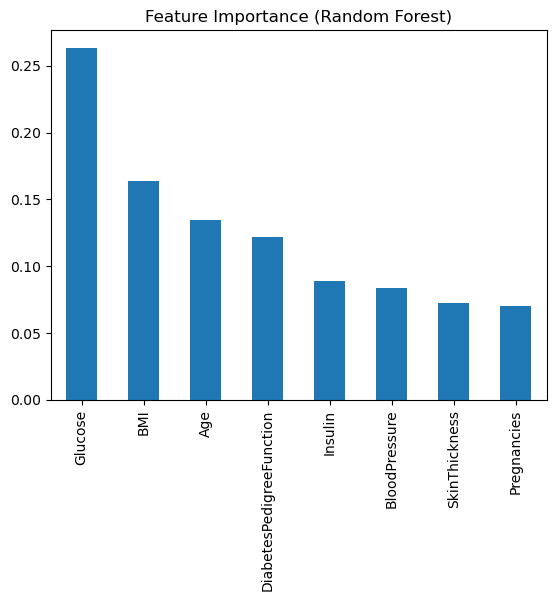

In [27]:
import pandas as pd

importance = rf_model.feature_importances_
features = X.columns

feat_importance = pd.Series(importance, index=features).sort_values(ascending=False)

feat_importance.plot(kind='bar')
plt.title('Feature Importance (Random Forest)')
plt.show()

## Feature Importance

The Random Forest model shows that Glucose, BMI, and Age are the most important features in predicting diabetes.

This aligns with the earlier visual analysis.